# 📚 Transfer Learning with CNNs and PyTorch

## 🎯 1. Objective

In this lab, you'll use **transfer learning** with a pretrained **ResNet18** to classify images from a reduced **CIFAR-10** dataset.

You'll:
- 🧬 Use transfer learning with pretrained ResNet18
- 🆚 Compare it with training from scratch
- 📊 Track training and validation loss
- 🧪 Evaluate on a separate test set

## 📦 2. Python Dependencies

To run this notebook, make sure you have the following packages installed:

```bash
pip install torch torchvision matplotlib scikit-learn seaborn
```

⚠️ If you're using Google Colab or a similar environment, most of these libraries are pre-installed.

## ⚙️ 3. Import Dependencies

In [1]:
%pip install seaborn

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


## 🗂️ 3. Load and Preprocess Dataset

* Download the CIFAR10 dataset and select only 3 of the classes. 
* Resize images to 224×224 to work with the pretrained model.
* Create a small dataset with only 200 images per class. 
* Split the dataset into three subsets for training (train, validation and test). 

In [2]:
# 📦 Transform
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# 🧪 Load CIFAR-10
full_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)

# 🎯 Keep only 3 classes
selected_classes = [0, 1, 2]
selected_indices = [i for i, (_, label) in enumerate(full_dataset) if label in selected_classes]

# 🎯 Limit to 200 samples per class
class_counts = {c: 0 for c in selected_classes}
limited_indices = []

for idx in selected_indices:
    label = full_dataset[idx][1]
    if class_counts[label] < 200:
        limited_indices.append(idx)
        class_counts[label] += 1
    if all(c >= 200 for c in class_counts.values()):
        break

reduced_dataset = Subset(full_dataset, limited_indices)

# 🧪 Split: 60% train / 20% val / 20% test
total_size = len(reduced_dataset)
train_size = int(0.6 * total_size)
val_size = int(0.2 * total_size)
test_size = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(reduced_dataset, [train_size, val_size, test_size])

# 🔄 DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


100%|██████████| 170498071/170498071 [00:30<00:00, 5652513.90it/s] 


Extracting ./data/cifar-10-python.tar.gz to ./data


## 🧬 4. Load Pretrained ResNet18

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"📡 Using device: {device}")

# 🔄 Load and freeze pretrained model
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
for param in model.parameters():
    param.requires_grad = False

# 🔧 Replace final layer
num_classes = len(selected_classes)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

# ⚙️ Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)


📡 Using device: cpu


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:04<00:00, 10.7MB/s]


## 🏋️‍♂️ 5. Train with Validation

In [4]:
def train_with_validation(model, device, train_loader, val_loader, criterion, optimizer, epochs=5):
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        running_train_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_train_loss += loss.item()

        # 🔍 Validation
        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                val_loss = criterion(outputs, labels)
                running_val_loss += val_loss.item()

        avg_train_loss = running_train_loss / len(train_loader)
        avg_val_loss = running_val_loss / len(val_loader)
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)

        print(f"📈 Epoch {epoch+1}/{epochs} - Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    return train_losses, val_losses

train_losses, val_losses = train_with_validation(model, device, train_loader, val_loader, criterion, optimizer)


📈 Epoch 1/5 - Train Loss: 1.0683 | Val Loss: 0.9200
📈 Epoch 2/5 - Train Loss: 0.7740 | Val Loss: 0.6541
📈 Epoch 3/5 - Train Loss: 0.5935 | Val Loss: 0.5891
📈 Epoch 4/5 - Train Loss: 0.5235 | Val Loss: 0.4730
📈 Epoch 5/5 - Train Loss: 0.4125 | Val Loss: 0.4327


## 📉 6. Visualize Training & Validation Loss

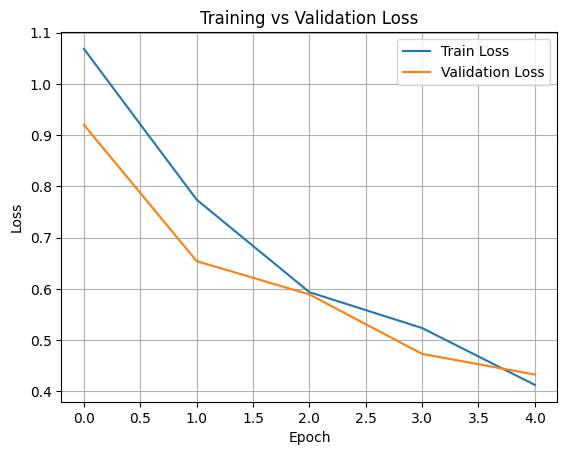

In [6]:
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


## 🧮  7. Final Evaluation on Test Set

🎯 Test Accuracy: 0.8167

📋 Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.68      0.80        57
           1       0.86      0.91      0.89        35
           2       0.64      0.96      0.77        28

    accuracy                           0.82       120
   macro avg       0.82      0.85      0.82       120
weighted avg       0.85      0.82      0.82       120



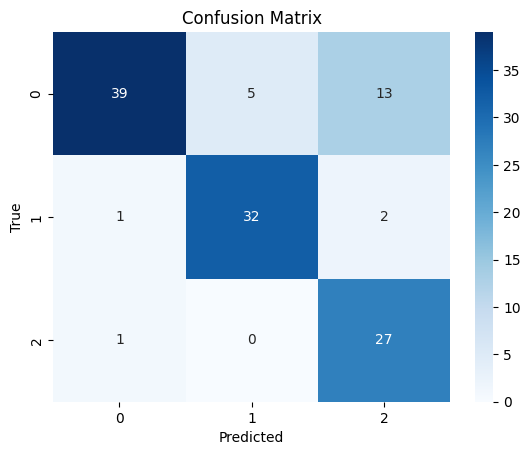

In [7]:
def evaluate_model(model, device, loader):
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = correct / total
    print(f"🎯 Test Accuracy: {accuracy:.4f}")
    print("\n📋 Classification Report:\n", classification_report(all_labels, all_preds))

    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

evaluate_model(model, device, test_loader)


## 🆚 8. Baseline: Training from Scratch

📈 Epoch 1/5 - Train Loss: 1.2277 | Val Loss: 8.0616
📈 Epoch 2/5 - Train Loss: 0.8272 | Val Loss: 3.6800
📈 Epoch 3/5 - Train Loss: 0.7203 | Val Loss: 2.1363
📈 Epoch 4/5 - Train Loss: 0.6798 | Val Loss: 0.6095
📈 Epoch 5/5 - Train Loss: 0.6037 | Val Loss: 0.7789
🎯 Test Accuracy: 0.6917

📋 Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.91      0.78        57
           1       0.70      0.46      0.55        35
           2       0.71      0.54      0.61        28

    accuracy                           0.69       120
   macro avg       0.70      0.64      0.65       120
weighted avg       0.69      0.69      0.68       120



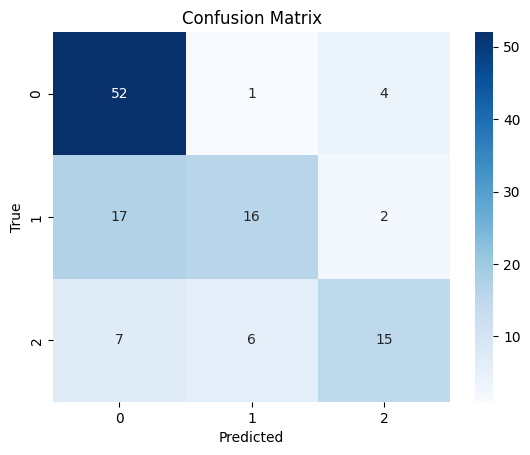

In [8]:
# 🔄 New ResNet without pretrained weights
model_scratch = models.resnet18(weights=None)
model_scratch.fc = nn.Linear(model_scratch.fc.in_features, num_classes)
model_scratch = model_scratch.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_scratch.parameters(), lr=0.001)

# 🔁 Train with validation
train_with_validation(model_scratch, device, train_loader, val_loader, criterion, optimizer)

# 🧪 Evaluate on test
evaluate_model(model_scratch, device, test_loader)


## 🤔 9. Discussion & Questions

1. ✅ Which model performed better — pretrained or scratch?
  *  The pretrained model performed better
3. 🧠 Why is transfer learning especially helpful with small datasets?
  * Transfer learning helps in the case for small datasets because it allows you to base your model on an already pre-trained one. This also helps reducing overfitting and accelerates the training process. Besides that, it helps when the data is limited, for example basing on the ImageNet dataset.
4. 🔧 In this experiment, we only trained the final fully connected layer of the pretrained ResNet18 model (i.e., all other layers were frozen). Which type of partial fine-tuning would you also apply in this scenario to improve the performance?
  * Depending also on the amount of data, we could improve the performance by using additional layers and not only the final one for the fine-tuning.
5. 💡 How would performance change if more classes or data were used?
  * Performance would porbably decrease as we'd be adding more complexity to the model. It'd become better for handling general images but it'd become heavier.

